<a href="https://colab.research.google.com/github/tanpaterusan/data-science-2026/blob/main/Pertemuan4_Amalia_240401010284.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pertemuan IV**

- Nama: Amalia
- NIM: 240401010284
- Kelas: IF403

In [ ]:
# Langkah 1: Load & Inspect Dataset

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')

print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

In [ ]:
# Langkah 2: Statistik Deskriptif Lengkap

for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')
    print(f'  Median   : {col.median():.3f}')
    print(f'  Std Dev  : {col.std():.3f}')
    print(f'  Skewness : {col.skew():.3f}')
    print(f'  Kurtosis : {col.kurt():.3f}')



=== sepal_length ===
  Mean     : 5.843
  Median   : 5.800
  Std Dev  : 0.828
  Skewness : 0.315
  Kurtosis : -0.552

=== sepal_width ===
  Mean     : 3.057
  Median   : 3.000
  Std Dev  : 0.436
  Skewness : 0.319
  Kurtosis : 0.228

=== petal_length ===
  Mean     : 3.758
  Median   : 4.350
  Std Dev  : 1.765
  Skewness : -0.275
  Kurtosis : -1.402

=== petal_width ===
  Mean     : 1.199
  Median   : 1.300
  Std Dev  : 0.762
  Skewness : -0.103
  Kurtosis : -1.341


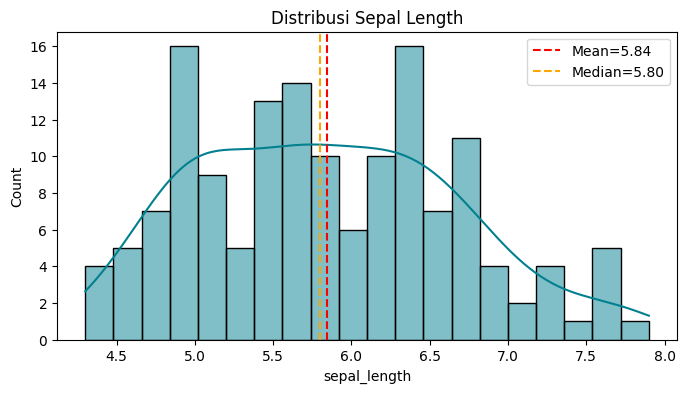

In [ ]:
# Langkah 3: Analisis Distribusi (Histogram + KDE)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
             color='#028090', bins=20, ax=ax)

ax.axvline(df['sepal_length'].mean(), color='red',
           linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")

ax.axvline(df['sepal_length'].median(), color='orange',
           linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()


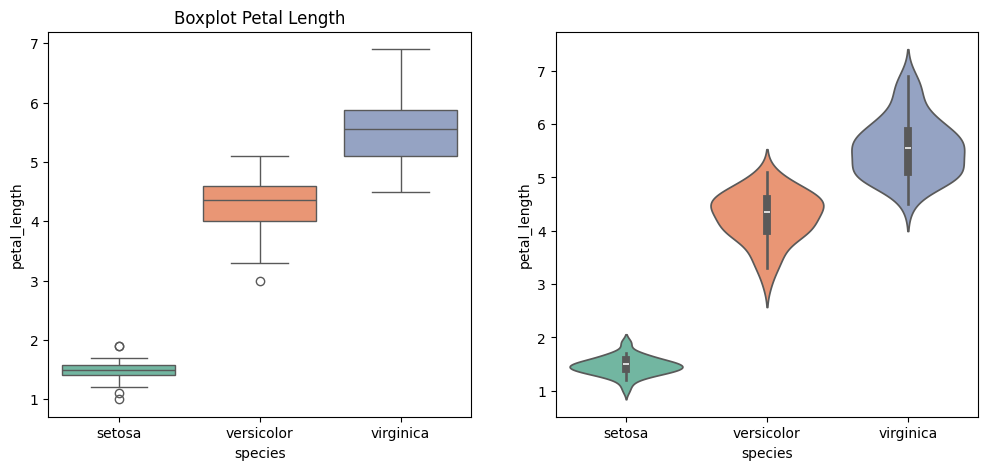

<Figure size 640x480 with 0 Axes>

In [ ]:
# Langkah 4: Boxplot per Spesies


import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length',
            palette='Set2', hue='species', legend=False, ax=axes[0])

axes[0].set_title('Boxplot Petal Length')

sns.violinplot(data=df, x='species', y='petal_length',
               palette='Set2', hue='species', legend=False, inner='box', ax=axes[1])
plt.show()

axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout(); plt.show()


In [ ]:
# Langkah 5: Matriks Korelasi Pearson

corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

import numpy as np

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()

print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


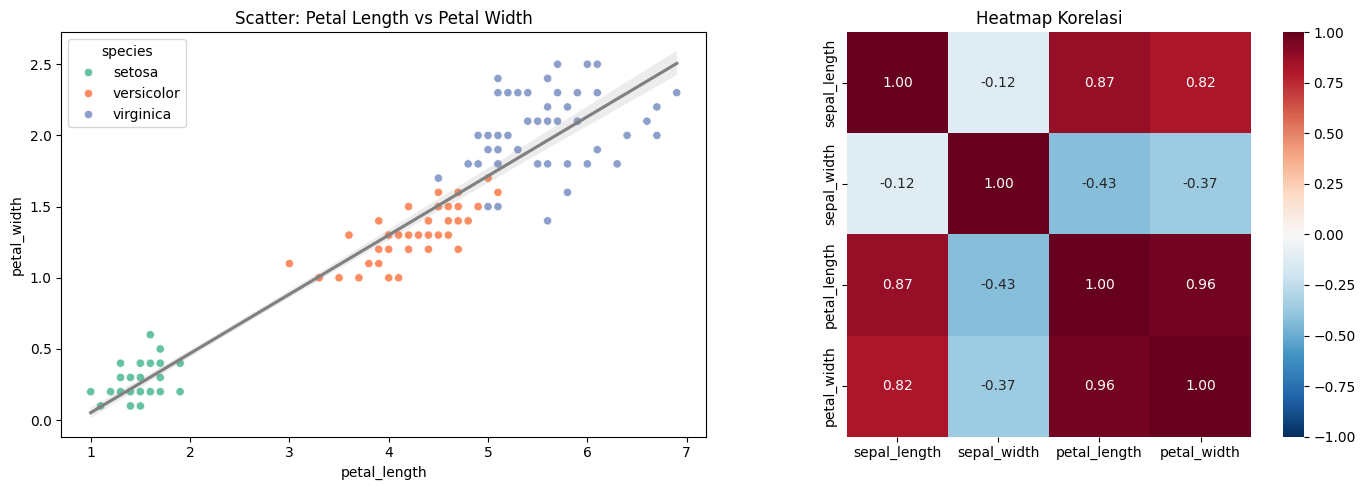

In [ ]:
# Langkah 6: Scatter Plot & Heatmap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', ax=axes[0])

sns.regplot(data=df, x='petal_length', y='petal_width',
            scatter=False, color='gray', ax=axes[0])

axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, ax=axes[1])

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout(); plt.show()

**Evaluasi**

1. Apa yang Saya Pelajari
- Eksplorasi Data Iris: Memahami dataset legendaris bunga Iris (150 baris, 5 kolom) yang berisi ukuran kelopak (petal) dan kelopak luar (sepal).

- Membaca Bentuk Distribusi: Belajar menggunakan nilai Skewness dan Kurtosis untuk melihat apakah data melengkung normal atau condong ke satu sisi.

- Garis Penanda Statistik: Cara menggambar garis vertikal putus-putus (axvline) untuk menandai posisi Mean (merah) dan Median (oranye) di dalam histogram.

- Visualisasi Distribusi Modern: Membandingkan Boxplot konvensional dengan Violin Plot yang bisa menunjukkan kepadatan bentuk data.

- Matriks Korelasi: Cara menghitung hubungan antar-variabel (.corr()) dan menyembunyikan setengah bagian matriks yang kembar menggunakan mask.



2. Temuan Utama Data
- Bentuk Data Sepal Length: Nilai Mean (5.84) dan Median (5.80) sangat mirip, didukung skewness kecil (0.315), artinya data menyebar cukup normal/seimbang.

- Keunikan Kelopak (Petal): Nilai kurtosis kelopak (petal) bernilai negatif tajam (~ -1.4). Ini indikasi kuat adanya dua kelompok data terpisah (bimodal).

- Korelasi Sangat Kuat: Panjang kelopak (petal_length) dan lebar kelopak (petal_width) punya hubungan positif yang hampir sempurna (nilai korelasi 0.963).

- Pemisahan Spesies: Lewat grafik Scatter Plot, terlihat jelas spesies Setosa mengelompok sendiri di area bawah karena ukuran kelopaknya yang sangat kecil dibanding Versicolor dan Virginica.


3. Keterbatasan & Pertanyaan Belajar
- Penumpukan Grafik Bug: Di Langkah 4, ada fungsi plt.show() yang dipanggil dua kali, sehingga memunculkan output teks error <Figure size 640x480 with 0 Axes>. Code ini kurang rapi.
- Korelasi Bias Campuran: Analisis korelasi Pearson (Langkah 5) menggabungkan semua spesies jadi satu. Apakah jika dihitung per spesies individu, nilai korelasinya akan tetap sama kuat?

- Mengapa Hanya Sepal Length?: Grafik histogram distribusi (Langkah 3) hanya dibuat untuk variabel sepal_length. Bagaimana dengan bentuk distribusi tiga variabel lainnya?

- Penentuan Batas Spesies: Melihat spesies Versicolor dan Virginica agak berhimpitan di scatter plot, metode statistik apa yang paling akurat untuk memisahkan keduanya secara otomatis?